### MAPE with CIs for whole-system scoring performance
### Julian Moran
### 2026-06-10

Condition 1: "pilot test"
- OCR for table ingestion
- If-else deterministic algorithm for scoring

<br>

Condition 2: "old"
- No OCR
- Three-shot agentic workforce for scoring

In [2]:
import logging
import os

import numpy as np
import polars as pl

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [3]:
# ============================================================
#   Args
# ============================================================

FILE_PILOT_DATA = f"./___eagleAI_performance_casewise_breakdown.tsv"
FILE_OLD_DATA = f"../wholeSystemPerformance_unscreened/EAGLE-AI_results/___EAGLE-AI_performance_bound_withPhen.tsv"
COLS_PILOT = {
    "ai": "EAGLE_AI_score",
    "manual": "Curator_score"
}
COLS_OLD = {
    "ai": "eagle_ai_score",
    "manual": "manual_score"
}
N_BOOTSTRAP_ITERATIONS = 1000

In [4]:
# ============================================================
#   In: Pilot data
# ============================================================

df_pilot = pl.read_csv(
    FILE_PILOT_DATA,
    separator="\t",
    null_values="NA",
    encoding="utf-lossy"
)
df_pilot

Gene,Paper,EAGLE_AI_case_ID,Curator_case_ID,EAGLE_AI_variant_ID,Curator_variant_ID,EAGLE_AI_phenotype,EAGLE_AI_confidence,Curator_phenotype,Curator_confidence,EAGLE_AI_score,Curator_score,Score_diff,Case_performance,Variant_performance,Phenotype_performance,Failure_mode,Failure_mode_support
str,str,str,str,str,str,str,str,str,str,f64,f64,f64,str,str,i64,str,str
"""CACNA1A""","""baldridge_2024""",null,null,null,null,null,null,null,null,0.0,0.0,0.0,"""TN""","""TN""",null,null,null
"""CACNA1A""","""castagnola_2018""",null,null,null,null,null,null,null,null,0.0,0.0,0.0,"""TN""","""TN""",null,null,null
"""CACNA1A""","""chen_2022""",null,"""D3""","""hg19:chr19:g.13394117G>A""",null,null,null,"""non-verbal at age 2.8y, decrea…",null,0.0,0.0,0.0,"""TN""","""TN""",null,null,null
"""CACNA1A""","""damaj_2019""","""Family 1 - Patient 4.1""","""Family 1, Patient 4.1""","""c.3832C>T (p.Arg1278Ter; NM_00…","""rs121909323""","""Moderate-severe global develop…","""Medium""","""generalized tonic-clonic seizu…","""Medium""",1.25,1.25,0.0,"""TP""","""TP""",100,null,null
"""CACNA1A""","""damaj_2019""",null,"""Family 1, Patient 3.2""",null,null,null,null,null,null,0.0,0.0,0.0,"""TN""","""TN""",null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CHD3""","""coursimault_2021""","""Proband_CHD3""","""Index case""","""chr17(GRCh37):g.7803326A>G""","""(GRCh37):g.7803326A>G""","""Male proband presenting with s…","""High""","""Diagnosis of ASD based on the …","""High""",0.5,0.5,0.0,"""TP""","""TP""",100,null,null
"""CHD3""","""pascual_2023""","""Family_12_son_among_P12-P14""","""Family 12; Patient 14""","""chr17:7903962 (hg38); NM_00100…","""hg38: chr17:7903962 ""","""Male child in Family 12, carry…","""High""","""ASD and moderate ID""","""High""",0.1,0.1,0.0,"""TP""","""TP""",100,null,null
"""CHD3""","""pascual_2023""",null,"""pascual_2023_P3""",null,null,null,null,"""ASD""",null,0.0,0.0,0.0,"""TN""","""TN""",null,null,null


In [48]:
# ============================================================
#   In: old data
# ============================================================

df_old = pl.read_csv(
    FILE_OLD_DATA,
    separator="\t",
    null_values="NA"
)
df_old

publication,gene,curator_assigned_case_id,eagle-ai_assigned_case_id,case_in_eagle,case_id_match,curator_assigned_variant_id,eagle-ai_variant_id,variant_in_eagle,variant_enough_info,variant_id_match,phenotype_accuracy_rating,manual_score,eagle_ai_score,score_diff,score_diff_reason,score_diff_sub_reason,reason_explanation,eagle-ai_phenotype,curator_phenotype
str,str,str,str,str,bool,str,str,str,bool,bool,i64,f64,f64,f64,str,str,str,str,str
"""tassinari_2023""","""CDKL5""","""mouse_KO_wang_2012""",null,"""FN""",false,null,null,null,null,null,null,2.0,0.0,2.0,"""missed_case""","""missed_external_paper""","""The mouse model seen here is o…",null,null
"""tassinari_2023""","""CDKL5""","""mouse_KO_ren_2019""","""CDD_Mouse_Model_01""","""TP""",false,null,null,null,null,null,null,2.0,3.0,1.0,"""discretion""","""discretion""",null,"""Autistic features, impaired ne…",null
"""tassinari_2023""","""CDKL5""","""mouse_KO_amendola_2014""",null,"""TN""",false,null,null,null,null,null,null,0.0,0.0,0.0,null,null,null,null,null
"""khan_2024""","""CDKL5""","""PKASD-18""","""PKASD-18""","""TP""",true,"""NM_003159.3:c.2626A>G""","""NM_003159.3:c.2626A>G; p.Ile87…","""TP""",true,false,8,0.1,0.1,0.0,null,null,null,"""ASD, intellectual disability, …","""ASD diagnosed by pediatrician;…"
"""khan_2024""","""CDKL5""","""codina_sola_CDKL5_P1""",null,"""FN""",false,"""p.Pro647Leu""",null,"""FN""",false,false,null,0.1,0.0,0.1,"""missed_case""","""bad_table_parsing""",null,null,"""ASD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""becker_2020""","""CASK""","""becker_2020_2018ASD_twin_2""",null,"""TN""",null,null,null,null,null,null,null,0.0,0.0,0.0,null,null,null,null,"""ASD features"""
"""becker_2020""","""CASK""","""becker_2020_2018_ID_P1""",null,"""TN""",null,null,null,null,null,null,null,0.0,0.0,0.0,null,null,null,null,"""intellectual disability"""
"""seto_2017""","""CASK""","""seto_2017_P1""","""Patient 1""","""TP""",false,"""NM_003688.3:c.1424G>T""","""chrX:41437672C>A, NM_003688.3(…","""TP""",true,false,8,0.1,0.5,0.4,"""failed_logic; missed_phenotype…","""ignored_variant_details; ignor…",null,"""ASD, intellectual disability, …","""ASD features; poor verbal comm…"


In [49]:
# ============================================================
#   Pilot MAPE (gene-wise)
# ============================================================

def compute_mape(ai_scores: list, manual_scores: list):
    """
    Description:
        - Given index-matched lists of AI scores and manual scores, compute MAPE
    """
    mape_values = [
        abs(a - m) / abs(m)
        for a, m in zip(ai_scores, manual_scores)
    ]
    mape = 100 * sum(mape_values) / len(mape_values)
    return round(mape, 2), mape_values

genewise_mape_pilot, _ = compute_mape(
    ai_scores=genewise_scores_pilot[COLS_PILOT["ai"]].to_list(),
    manual_scores=genewise_scores_pilot[COLS_PILOT["manual"]].to_list()
)

genewise_scores_pilot = (
    df_pilot
    .group_by("Gene")
    .agg([
        pl.col(COLS_PILOT["ai"]).sum(),
        pl.col(COLS_PILOT["manual"]).sum(),
    ])
    .rename({"Gene": "gene"})
    .with_columns(
        (
            pl.col(COLS_PILOT["ai"])
            - pl.col(COLS_PILOT["manual"])
        ).abs().alias("abs_score_diff")
    )
).sort("gene")

print(genewise_scores_pilot)
logger.info(f"Gene-wise MAPE (pilot): {genewise_mape_pilot}%")

INFO:__main__:Gene-wise MAPE (pilot): 27.02%


shape: (8, 4)
┌─────────┬────────────────┬───────────────┬────────────────┐
│ gene    ┆ EAGLE_AI_score ┆ Curator_score ┆ abs_score_diff │
│ ---     ┆ ---            ┆ ---           ┆ ---            │
│ str     ┆ f64            ┆ f64           ┆ f64            │
╞═════════╪════════════════╪═══════════════╪════════════════╡
│ CACNA1A ┆ 5.75           ┆ 5.0           ┆ 0.75           │
│ CASK    ┆ 2.0            ┆ 4.6           ┆ 2.6            │
│ CDKL5   ┆ 0.7            ┆ 13.1          ┆ 12.4           │
│ CHAMP1  ┆ 5.0            ┆ 5.0           ┆ 0.0            │
│ CHD3    ┆ 0.6            ┆ 0.6           ┆ 0.0            │
│ FMR1    ┆ 2.0            ┆ 2.0           ┆ 0.0            │
│ GIGYF2  ┆ 2.0            ┆ 4.0           ┆ 2.0            │
│ GRIN1   ┆ 0.2            ┆ 0.2           ┆ 0.0            │
└─────────┴────────────────┴───────────────┴────────────────┘


In [50]:
# ============================================================
#   Old MAPE (gene-wise)
# ============================================================

genewise_scores_old = (
    df_old
    .group_by("gene")
    .agg([
        pl.col(COLS_OLD["ai"]).sum(),
        pl.col(COLS_OLD["manual"]).sum(),
    ])
    .with_columns(
        (
            pl.col(COLS_OLD["ai"])
            - pl.col(COLS_OLD["manual"])
        ).abs().alias("abs_score_diff")
    )
).sort("gene")

genewise_mape_old, _ = compute_mape(
    ai_scores=genewise_scores_old[COLS_OLD["ai"]].to_list(),
    manual_scores=genewise_scores_old[COLS_OLD["manual"]].to_list()
)

print(genewise_scores_old)
logger.info(f"Gene-wise MAPE (old): {genewise_mape_old}%")

INFO:__main__:Gene-wise MAPE (old): 73.69%


shape: (8, 4)
┌─────────┬────────────────┬──────────────┬────────────────┐
│ gene    ┆ eagle_ai_score ┆ manual_score ┆ abs_score_diff │
│ ---     ┆ ---            ┆ ---          ┆ ---            │
│ str     ┆ f64            ┆ f64          ┆ f64            │
╞═════════╪════════════════╪══════════════╪════════════════╡
│ CACNA1A ┆ 3.35           ┆ 5.0          ┆ 1.65           │
│ CASK    ┆ 2.6            ┆ 4.6          ┆ 2.0            │
│ CDKL5   ┆ 5.5            ┆ 13.1         ┆ 7.6            │
│ CHAMP1  ┆ 14.0           ┆ 5.0          ┆ 9.0            │
│ CHD3    ┆ 0.6            ┆ 0.6          ┆ 0.0            │
│ FMR1    ┆ 6.5            ┆ 2.0          ┆ 4.5            │
│ GIGYF2  ┆ 2.0            ┆ 4.0          ┆ 2.0            │
│ GRIN1   ┆ 0.1            ┆ 0.1          ┆ 0.0            │
└─────────┴────────────────┴──────────────┴────────────────┘


In [ ]:
# ============================================================
#   Bootstrap CI of MAPE difference
# ============================================================

def compute_mape_bootstrap(ai_scores: list, manual_scores: list):
    mape_values = []
    for a, m in zip(ai_scores, manual_scores):
        if (m == 0) and (abs(a - m) != 0):
            mape_value = 1.0 # If ground truth is 0 and model output is not 0, error is coerced to 100%.
        elif (m == 0) and (abs(a - m) == 0):
            mape_value = 0.0
        else:
            mape_value = abs(a - m) / abs(m)
        mape_values.append(mape_value)

    mape = 100 * sum(mape_values) / len(mape_values)
    return round(mape, 2), mape_values

rng = np.random.default_rng()
boot_diffs = []
for i in range(N_BOOTSTRAP_ITERATIONS):
    pilot_idx = rng.integers(0, len(df_pilot), len(df_pilot))
    old_idx = rng.integers(0, len(df_old), len(df_old))

    df_pilot_boot = df_pilot[pilot_idx]
    df_old_boot = df_old[old_idx]
    
    genewise_scores_pilot_boot = (
        df_pilot_boot
        .group_by("Gene")
        .agg([
            pl.col(COLS_PILOT["ai"]).sum(),
            pl.col(COLS_PILOT["manual"]).sum(),
        ])
        .rename({"Gene": "gene"})
        .sort("gene")
    )
    genewise_scores_old_boot = (
        df_old_boot
        .group_by("gene")
        .agg([
            pl.col(COLS_OLD["ai"]).sum(),
            pl.col(COLS_OLD["manual"]).sum(),
        ])
        .sort("gene")
    )
    
    mape_pilot, _ = compute_mape_bootstrap(
        ai_scores=genewise_scores_pilot_boot[COLS_PILOT["ai"]].to_list(),
        manual_scores=genewise_scores_pilot_boot[COLS_PILOT["manual"]].to_list()
    )
    mape_old, _ = compute_mape_bootstrap(
        ai_scores=genewise_scores_old_boot[COLS_OLD["ai"]].to_list(),
        manual_scores=genewise_scores_old_boot[COLS_OLD["manual"]].to_list()
    )
    boot_diffs.append(mape_old - mape_pilot)

ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
logger.info(f"Diff: {abs(genewise_mape_pilot - genewise_mape_old)} %age points")
logger.info(f"[{round(ci_lower, 2)}, {round(ci_upper, 2)}]")

INFO:__main__:Diff: 46.67 %age points
INFO:__main__:[-22.56, 172.61]


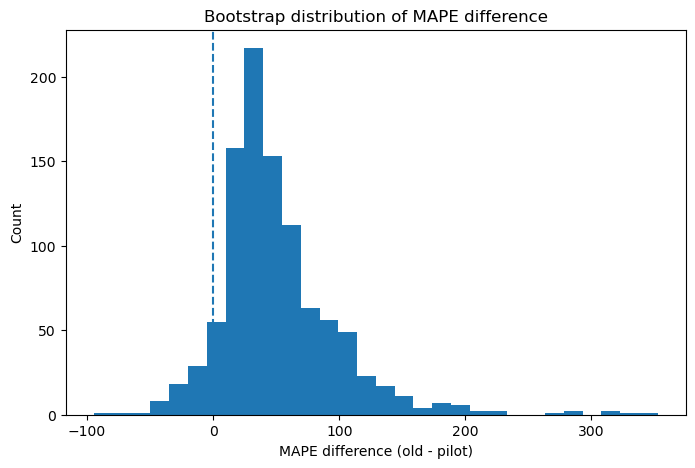

In [53]:
# ============================================================
#   Plot
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(boot_diffs, bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("MAPE difference (old - pilot)")
plt.ylabel("Count")
plt.title("Bootstrap distribution of MAPE difference")
plt.show()